# 03 — Exploratory Data Analysis

Business questions this notebook answers:

* How imbalanced is churn?
* Which customer segments have the highest churn?
* Does contract type influence churn?
* Does customer tenure relate to churn?
* Are higher charges associated with churn?
* Which services are associated with higher churn?

Every figure is saved to `reports/figures/` for the README.

In [1]:
import sys
sys.path.insert(0, 'C:\\Users\\OUISSAL\\Production-Ready Customer Churn')  # make 'src' importable
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import config
from src.data_preprocessing import (
    clean_data, encode_target, load_raw_data,
)
from src.feature_engineering import add_features

sns.set_theme(style='whitegrid', palette='muted')

df = clean_data(load_raw_data())
df['Churn'] = encode_target(df)
df['Churn_label'] = np.where(df['Churn'] == 1, 'Yes', 'No')
engineered = add_features(df.drop(columns=['customerID']))
engineered['Churn'] = df['Churn'].values
print(f'rows={len(df)}, churn rate={df["Churn"].mean():.1%}')

rows=7043, churn rate=26.5%


## 1. Churn distribution

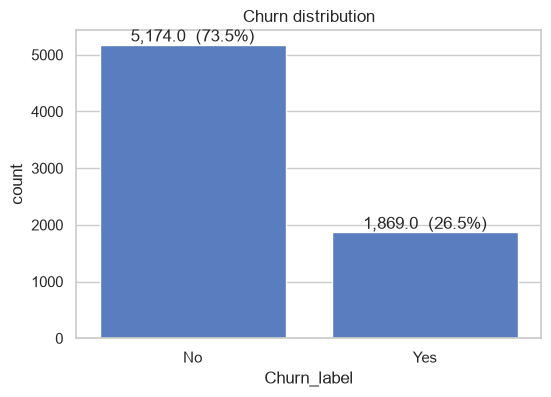

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='Churn_label', ax=ax,
              order=['No', 'Yes'])
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():,}'
                f'  ({bar.get_height()/len(df):.1%})',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom')
ax.set_title('Churn distribution')
fig.savefig(config.FIGURES_DIR / 'eda_churn_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 2. Does tenure relate to churn?

Churn risk is concentrated in the first months of the relationship.

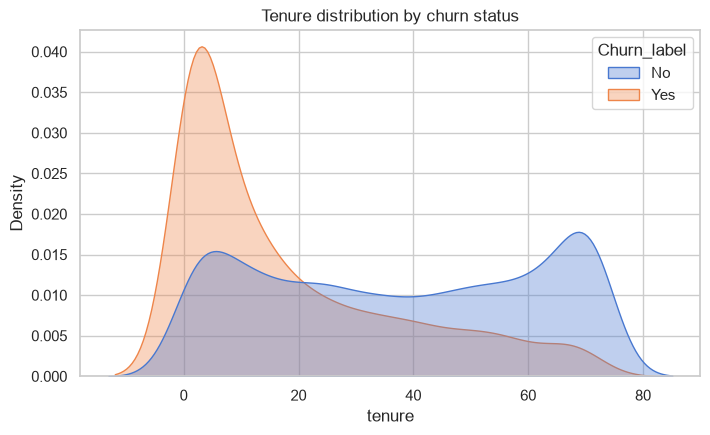

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.kdeplot(data=df, x='tenure', hue='Churn_label',
            fill=True, alpha=0.35, common_norm=False, ax=ax)
ax.set_title('Tenure distribution by churn status')
fig.savefig(config.FIGURES_DIR / 'eda_tenure_churn.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 3. Does contract type influence churn?

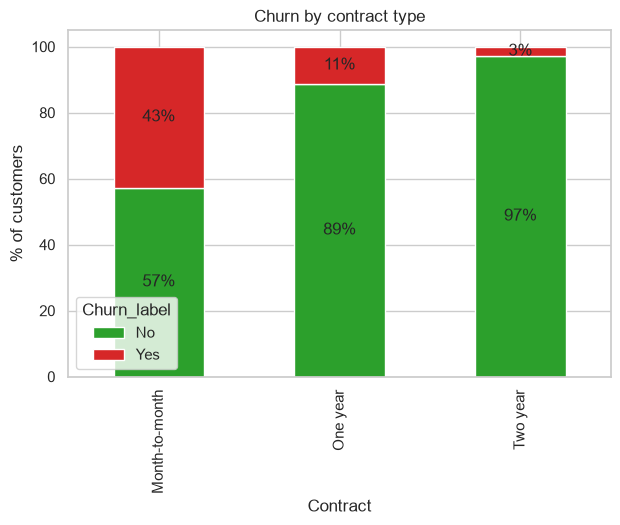

Churn rate by contract:
Contract
Month-to-month    0.427
One year          0.113
Two year          0.028


In [4]:
ct = pd.crosstab(df['Contract'], df['Churn_label'],
                 normalize='index') * 100
ax = ct[['No', 'Yes']].plot(kind='bar', stacked=True,
                          figsize=(7, 4.5),
                          color=['#2ca02c', '#d62728'])
ax.set_ylabel('% of customers')
ax.set_title('Churn by contract type')
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', label_type='center')
fig = ax.get_figure()
fig.savefig(config.FIGURES_DIR / 'eda_churn_by_contract.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Churn rate by contract:')
print(df.groupby('Contract')['Churn'].mean().round(3).to_string())

## 4. Payment method vs churn

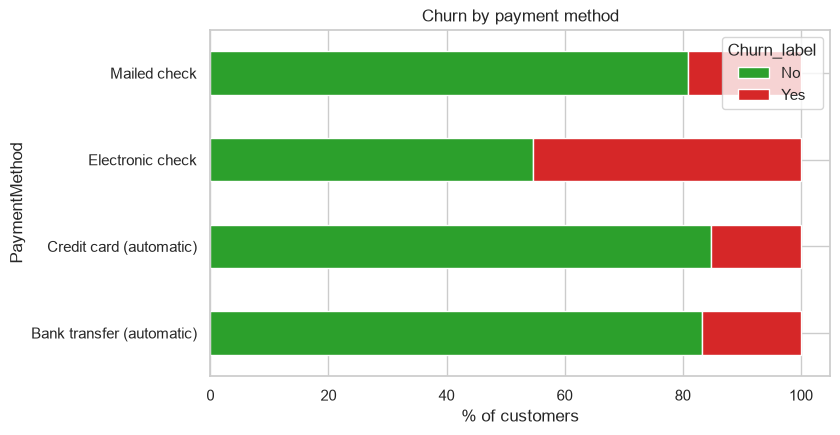

Churn rate by payment method:
PaymentMethod
Bank transfer (automatic)    0.167
Credit card (automatic)      0.152
Electronic check             0.453
Mailed check                 0.191


In [5]:
ct = pd.crosstab(df['PaymentMethod'], df['Churn_label'],
                 normalize='index') * 100
ax = ct[['No', 'Yes']].plot(kind='barh', stacked=True,
                          figsize=(8, 4.5),
                          color=['#2ca02c', '#d62728'])
ax.set_xlabel('% of customers')
ax.set_title('Churn by payment method')
fig = ax.get_figure()
fig.savefig(config.FIGURES_DIR / 'eda_churn_by_payment.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Churn rate by payment method:')
print(df.groupby('PaymentMethod')['Churn'].mean().round(3).to_string())

## 5. Internet service & subscribed services

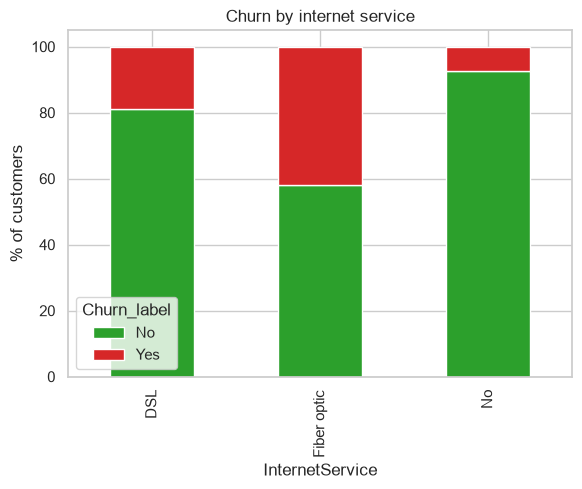

Churn rate by internet service:
InternetService
DSL            0.190
Fiber optic    0.419
No             0.074


In [6]:
ct = pd.crosstab(df['InternetService'], df['Churn_label'],
                 normalize='index') * 100
ax = ct[['No', 'Yes']].plot(kind='bar', stacked=True,
                          figsize=(6.5, 4.5),
                          color=['#2ca02c', '#d62728'])
ax.set_ylabel('% of customers')
ax.set_title('Churn by internet service')
fig = ax.get_figure()
fig.savefig(config.FIGURES_DIR / 'eda_churn_by_internet.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Churn rate by internet service:')
print(df.groupby('InternetService')['Churn'].mean().round(3).to_string())

## 6. Are higher charges associated with churn?

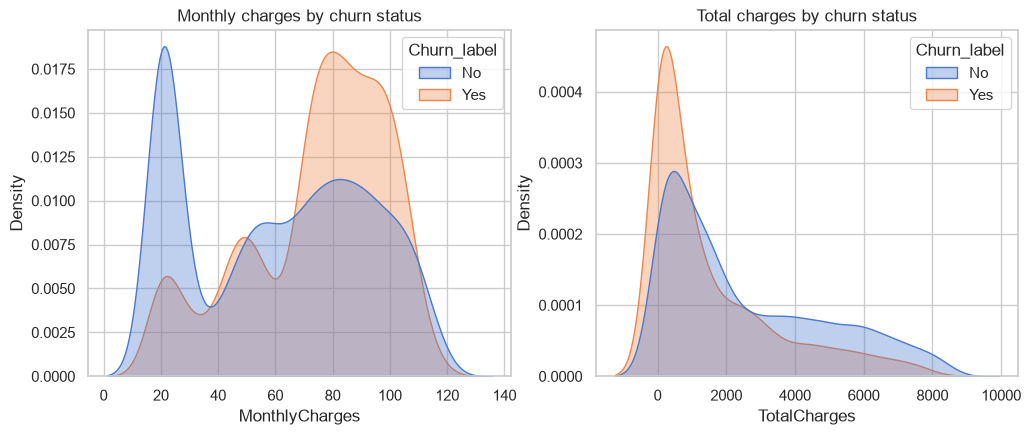

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn_label',
            fill=True, alpha=0.35, common_norm=False, ax=axes[0])
axes[0].set_title('Monthly charges by churn status')
sns.kdeplot(data=df, x='TotalCharges', hue='Churn_label',
            fill=True, alpha=0.35, common_norm=False, ax=axes[1])
axes[1].set_title('Total charges by churn status')
fig.savefig(config.FIGURES_DIR / 'eda_charges_by_churn.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Correlation structure of the numerical features

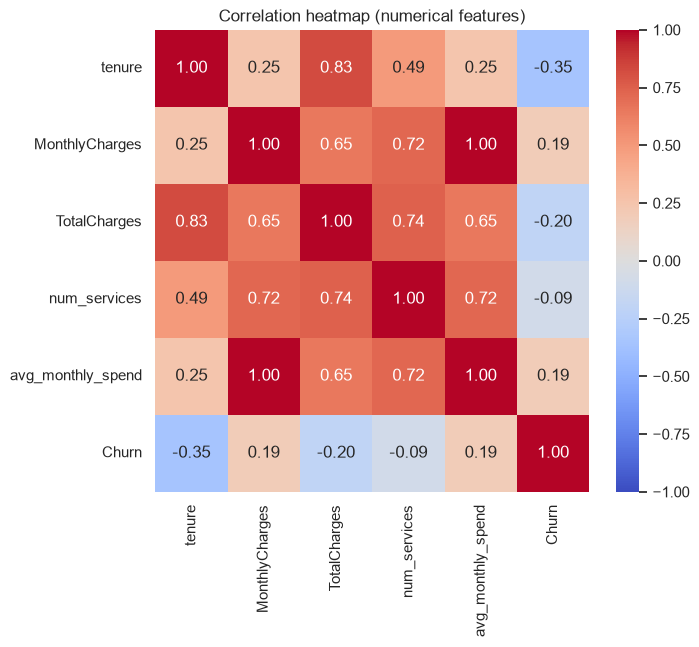

In [8]:
numeric = engineered[['tenure', 'MonthlyCharges', 'TotalCharges',
                     'num_services', 'avg_monthly_spend', 'Churn']]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(numeric.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation heatmap (numerical features)')
fig.savefig(config.FIGURES_DIR / 'eda_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 8. Churn rate by tenure group (engineered feature)

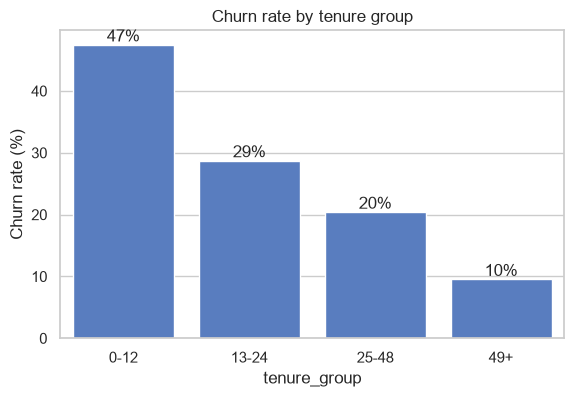

In [9]:
rate = engineered.groupby('tenure_group', observed=True)['Churn'].mean()
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.barplot(x=rate.index, y=rate.values * 100, ax=ax)
for i, v in enumerate(rate.values * 100):
    ax.text(i, v, f'{v:.0f}%', ha='center', va='bottom')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn rate by tenure group')
fig.savefig(config.FIGURES_DIR / 'eda_churn_by_tenure_group.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 9. Interactive view (Plotly)

In [10]:
import plotly.express as px

pivot = engineered.pivot_table(
    index='Contract', columns='PaymentMethod',
    values='Churn', aggfunc='mean',
) * 100
px.imshow(
    pivot.round(1), text_auto='.1f',
    color_continuous_scale='Reds', aspect='auto',
    title='Churn rate (%) by contract type and payment method',
    labels=dict(x='Payment method', y='Contract type', color='Churn %'),
)

## Key insights

* **Contract type is the strongest signal**: ~43% of month-to-month customers churn vs ~3% of two-year contracts.
* **Tenure**: churn risk collapses after the first 12 months.
* **Charges**: higher monthly charges (fiber-optic bundles) are associated with churn; total charges mainly mirror tenure.
* **Payment**: electronic-check payers churn much more than automatic credit-card payers.
* **Internet**: fiber-optic customers churn more than DSL or no-internet customers.

These patterns are exactly what the engineered features (tenure groups, service count, average monthly spend) aim to capture for the models.